In [1]:
!pip install graphviz


# Tree Visualizer

In [1]:
from graphviz import Digraph

def visualize_tree(tree):
    if tree is None: return 'Nothing in the tree!'
    def add_nodes_edges(tree, dot=None):
        # Creating Digraph object
        if dot is None:
            dot = Digraph()
            dot.attr('node', shape='circle')
            dot.node(name=str(tree), label=str(tree.val))

        for child in [tree.left, tree.right]:   # do for all childrens
            if child is not None:
                if child == tree.left:
                    dot.attr('node', shape='circle', style='filled', fillcolor='lightblue')
                if child == tree.right: 
                    dot.attr('node', shape='doublecircle', style='filled', fillcolor='lightsalmon')
                dot.node(name=str(child), label=str(child.val))
                dot.edge(str(tree), str(child))
                dot = add_nodes_edges(child, dot=dot)  # recursive call 

        return dot

    # Add nodes recursively and create a list of edges
    dot = add_nodes_edges(tree)

    # Visualize the graph
    display(dot)

# Print Tree

In [2]:
# helper fun
def helper(node, level):
    if node.left:
        print(' ' * (level * 3) + 'L: ' + str(node.left.val))
        helper(node.left, level + 1)
    if node.right:
        print(' ' * (level * 3) + 'R: ' + str(node.right.val))
        helper(node.right, level + 1)

def print_tree(node):
    if node is not None:
        print('.:' + str(node.val))
        helper(node, 1)

# TREE

A Tree is conceptually very similar to a linked list

In [3]:
class TreeNode:
    def __init__(self, x):
        self.val = x
        self.left = None
        self.right = None

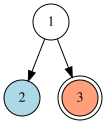

.:1
   L: 2
   R: 3


In [4]:
# tree
t1 = TreeNode(1)

t1.left = TreeNode(2)
t1.right = TreeNode(3)

visualize_tree(t1)     # this function needs a bit extra effort
print_tree(t1)         # we can use this function easily

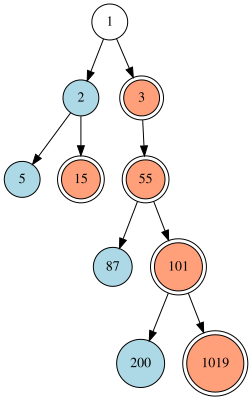

.:1
   L: 2
      L: 5
      R: 15
   R: 3
      R: 55
         L: 87
         R: 101
            L: 200
            R: 1019


In [5]:
# Let's confuse ouselves
t1.left.left = TreeNode(5)
t1.left.right = TreeNode(15)

t1.right.right = TreeNode(55)
t1.right.right.left = TreeNode(87)
t1.right.right.right = TreeNode(101)
t1.right.right.right.right = TreeNode(1019)
t1.right.right.right.left = TreeNode(200)

visualize_tree(t1)
print_tree(t1)

# Tree Traversal - Depth First Search

DFS has three stratiges
1. preorder DFS              [ Root --> Left_Subtree --> Right_Subtree ]
2. inorder DFS               [ Left_Subtree --> Root --> Right_Subtree ]
3. postorder DFS             [ Left_Subtree --> Right_Subtree --> Root ]

In [6]:
# pre_order DFS
def preorder_DFS(self):
    print(self.val)     # process on nodes, here process is print node

    if self.left:
        self.left.preorder_DFS()
    if self.right:
        self.right.preorder_DFS()

TreeNode.preorder_DFS = preorder_DFS

In [7]:
t1.preorder_DFS()
# visualize_tree(t1)
# print_tree(t1)

1
2
5
15
3
55
87
101
200
1019


In [8]:
# in_order DFS
def inorder_DFS(self):
    if self.left:
        self.left.inorder_DFS()

    print(self.val)     # process on nodes, here process is print node
        
    if self.right:
        self.right.inorder_DFS()

TreeNode.inorder_DFS = inorder_DFS

In [9]:
t1.inorder_DFS()
# visualize_tree(t1)
# print_tree(t1)

5
2
15
1
3
87
55
200
101
1019


In [10]:
# post_order DFS
def postorder_DFS(self):
    if self.left:
        self.left.postorder_DFS()
    if self.right:
        self.right.postorder_DFS()

    print(self.val)     # process on nodes, here process is print node

TreeNode.postorder_DFS = postorder_DFS

In [11]:
t1.postorder_DFS()
# visualize_tree(t1)
# print_tree(t1)

5
15
2
87
200
1019
101
55
3
1


# Tree Traversal - Breadth First Search

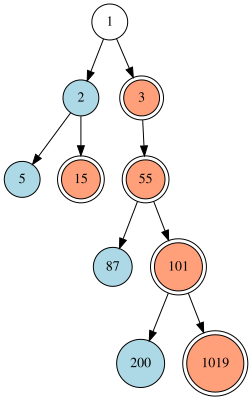

In [12]:
visualize_tree(t1)

In [14]:
def BFS(self):

    to_visit = [ self ]

    while to_visit:
        current = to_visit.pop(0)        # get the first one out from queue

        print(current.val)
        
        if current.left:
            to_visit.append(current.left)
        if current.right:
            to_visit.append(current.right)

TreeNode.BFS = BFS

In [15]:

t1.BFS()

1
2
3
5
15
55
87
101
200
1019


# Binary Search Tree

In [16]:
class BST(TreeNode):
    def __init__(self, val, parent = None):
        super().__init__(val)
        self.parent = parent

# Inserting Node In BST

In [17]:
def insert(self, val):

    if val == self.val:
        return
    
    if val < self.val: # insert to left if val is less then parent
        if self.left is None:
            new_node = BST(val, parent = self)
            self.left = new_node
        else:
            self.left.insert(val)

    else: # insert to right if val is greater then parent
        if self.right is None:
            new_node = BST(val, parent = self)
            self.right = new_node
        else:
            self.right.insert(val)


BST.insert = insert

In [18]:
b = BST(20)
print(b.val)

20


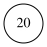

In [19]:
visualize_tree(b)

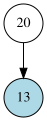

In [20]:
b.insert(13)
visualize_tree(b)

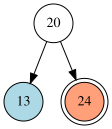

In [21]:
b.insert(24)
visualize_tree(b)

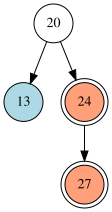

In [22]:
b.insert(27)
visualize_tree(b)

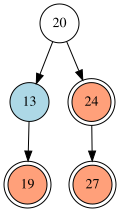

In [23]:
b.insert(19)
visualize_tree(b)

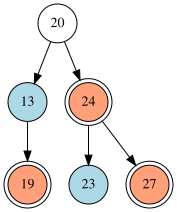

In [24]:
b.insert(23)
visualize_tree(b)

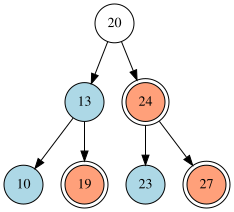

In [25]:
b.insert(10)
visualize_tree(b)

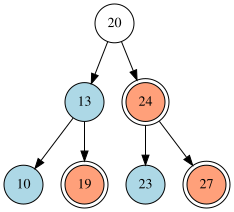

In [26]:
b.insert(13)
visualize_tree(b)

# Searching In BST

In [27]:
def search(self, val):
    if val == self.val:
        return True
    elif val < self.val:
        if self.left is None:
            return False    # val not found
        else:
            return self.left.search(val)
    else:
        if self.right is None:
            return False   # val not found
        else:
            return self.right.search(val)
    

BST.search = search

In [28]:
b.search(10)

True

# Deleting a Node from BST

Some helper function we'll need.

In [29]:
def find_root(self):
    """Find the absolute root of the BST to which self belongs. keep going until you get your node"""

    temp = self
    while temp.parent is not None:
        temp = temp.parent

    return temp
    # keep going until no parent ....... return that

BST.find_root = find_root

In [30]:
def find_min(self):
    """Find the minimum value starting from self.
    In BST, this is simple, keep going left until no more left is left!"""

    min_node = self

    while min_node.left is not None:
        min_node = min_node.left

    return min_node

BST.find_min = find_min

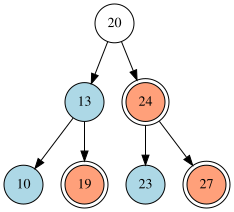

Min:  10


In [31]:
visualize_tree(b)
print("Min: ", b.find_min().val)

In [32]:
def set_for_parent(self, new_ref):
    """Disconnect self from parent and attach new_ref to parent in self's place"""

    if self.parent is None: return

    if self.parent.right == self:
        self.parent.right = new_ref

    if self.parent.left == self:
        self.parent.left = new_ref

BST.set_for_parent = set_for_parent

In [33]:
def replace_with_node(self, node):
    """Replace self with node (which is a child). Make sure to fix the parent of the node.
    Assume we have no children other then node."""

    self.set_for_parent(node)       # connect new node to parent on proper location
    node.parent = self.parent       # set's node parent correctly
    return node.find_root()

BST.replace_with_node = replace_with_node

In [34]:
def delete(self, val):
    # first ... if we are alone, on the root and no children plus the value matches just return None
    if self.parent is None and self.right is None and self.left is None and self.val == val:
        return None

    # if we are the node to be deleted
    if self.val == val:
        # check if we are leaf node
        if self.right is None and self.left is None:
            self.set_for_parent(None)        # set in place of self None
            return self.find_root()

        # check if we have just one left node
        if self.right is None:
            return self.replace_with_node(self.left)
        
        # check if we have just one right node
        if self.left is None:
            return self.replace_with_node(self.right)


        # check if we have both childrens. Find successor and replace "self" with it.
        # (Our Succ is definitely in  our right child and it can't have two children because left child will always be smaller.)
        successor = self.right.find_min()

        # copy successor's val here
        self.val = successor.val

        return self.right.delete(successor.val)
        # ^ delete the successor node, which is in our right child BST.
        # ^ It's guaranted that it's the simpler case since successor CANNOT have a left child.
        

    # if were not the node to be deleted, go to left if val is less else go to right
    if val < self.val:
        if self.left:
            return self.left.delete(val)
        else:
            return self.find_root()   # nothing  to delete
    else:
        if self.right:
            return self.right.delete(val)
        else:
            return self.find_root()    # nothing  to delete

BST.delete = delete        

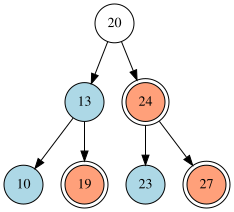

In [35]:
visualize_tree(b)

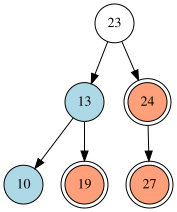

In [36]:
b = b.delete(20)
visualize_tree(b)

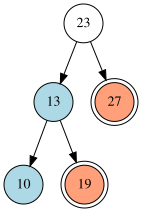

In [37]:
b = b.delete(24)
visualize_tree(b)

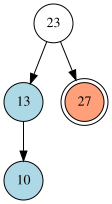

In [38]:
b = b.delete(19)
visualize_tree(b)

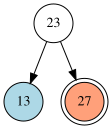

In [39]:
b = b.delete(10)
visualize_tree(b)

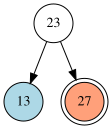

In [40]:
b = b.delete(20)
visualize_tree(b)